# Implementación de KMeans desde cero

Notebook completo y documentado línea por línea.

## CELDA 1 — Importar librerías

In [10]:
import numpy as np                     # Operaciones matemáticas y arreglos
import matplotlib.pyplot as plt       # Librería para gráficas

from sklearn.datasets import load_iris   # Dataset Iris
from sklearn.preprocessing import StandardScaler  # Normalización

### Conclusión
En esta parte se cargan las librerías necesarias para:
- manejar datos numéricos,
- graficar resultados,
- cargar el dataset Iris,
- y normalizar los datos antes del clustering.


## CELDA 2 — Cargar dataset

In [11]:
iris = load_iris()                    # Carga el dataset Iris

X = iris.data[:, :2]                  # Selecciona solo 2 variables para graficar en 2D

print(X[:5])                          # Muestra las primeras filas

[[5.1 3.5]
 [4.9 3. ]
 [4.7 3.2]
 [4.6 3.1]
 [5.  3.6]]


### Conclusión
Se usan únicamente dos características del dataset para visualizar fácilmente los clusters en 2D.


## CELDA 3 — Normalizar datos

In [12]:
scaler = StandardScaler()             # Crear objeto normalizador

X = scaler.fit_transform(X)           # Normaliza los datos

### Conclusión
La normalización evita que una variable tenga más peso que otra debido a diferencias de escala.


## CELDA 4 — Graficar datos originales

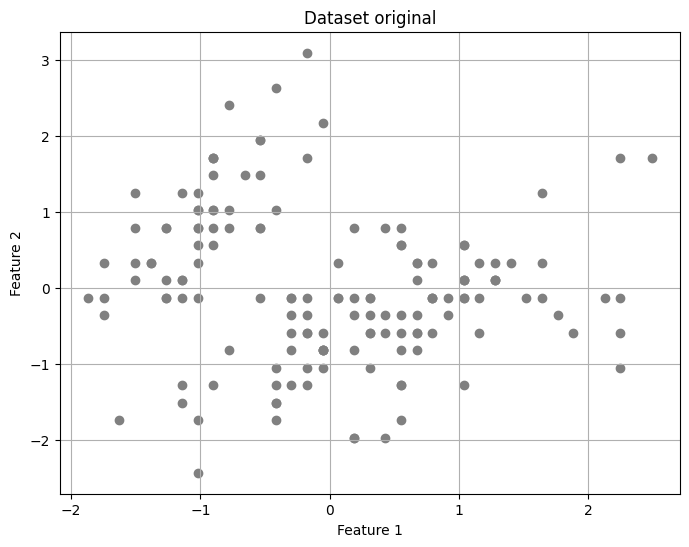

In [13]:
plt.figure(figsize=(8,6))             # Tamaño de figura

plt.scatter(
    X[:,0],                           # Valores eje X
    X[:,1],                           # Valores eje Y
    color='gray'                      # Color de los puntos
)

plt.title("Dataset original")         # Título
plt.xlabel("Feature 1")               # Etiqueta eje X
plt.ylabel("Feature 2")               # Etiqueta eje Y

plt.grid(True)                        # Activar cuadrícula

plt.show()                            # Mostrar gráfica

### Conclusión
La gráfica permite observar agrupaciones naturales en los datos.


## CELDA 5 — Distancia Euclidiana

In [14]:
def euclidean_distance(a, b):

    return np.sqrt(np.sum((a - b) ** 2))   # Fórmula distancia euclidiana

### Conclusión
La distancia euclidiana permite medir qué tan cerca está un punto de cada centroide.


## CELDA 6 — Implementación de KMeans desde cero

In [15]:
def kmeans(X, K, max_iters=100):

    n_samples, n_features = X.shape    # Número de muestras y variables

    random_idx = np.random.choice(n_samples, K, replace=False)
                                          # Escoge centroides iniciales aleatorios

    centroids = X[random_idx]             # Define centroides iniciales

    for _ in range(max_iters):            # Iteraciones máximas

        clusters = [[] for _ in range(K)] # Lista vacía para clusters

        for idx, sample in enumerate(X):  # Recorre cada punto

            distances = [                 # Distancia a cada centroide
                euclidean_distance(sample, point)
                for point in centroids
            ]

            closest = np.argmin(distances) # Centroide más cercano

            clusters[closest].append(idx)  # Guarda índice del punto

        old_centroids = centroids.copy()   # Copia centroides anteriores

        for cluster_idx, cluster in enumerate(clusters):

            if cluster:                    # Si el cluster no está vacío

                cluster_mean = np.mean(
                    X[cluster], axis=0
                )

                centroids[cluster_idx] = cluster_mean
                                               # Nuevo centroide promedio

        if np.all(old_centroids == centroids):
                                              # Verifica convergencia

            break

    labels = np.zeros(n_samples)             # Arreglo etiquetas

    for cluster_idx, cluster in enumerate(clusters):

        for sample_idx in cluster:

            labels[sample_idx] = cluster_idx
                                            # Asignar etiqueta

    inertia = 0                             # Inicializa inercia

    for cluster_idx, cluster in enumerate(clusters):

        for sample_idx in cluster:

            inertia += euclidean_distance(
                X[sample_idx],
                centroids[cluster_idx]
            ) ** 2
                                           # Suma distancias cuadradas

    return labels, centroids, inertia

### Conclusión
Aquí se implementa KMeans manualmente:
1. Inicializa centroides aleatorios.
2. Asigna cada punto al centroide más cercano.
3. Recalcula centroides usando promedios.
4. Repite hasta converger.


## CELDA 7 — Probar varios valores de K

In [16]:
K_values = range(1, 11)              # Valores K desde 1 hasta 10

best_inertias = []                   # Lista para guardar mejores inercias

for K in K_values:                   # Recorre cada K

    best_inertia = np.inf            # Inicializa con infinito

    for attempt in range(5):         # 5 intentos aleatorios

        labels, centroids, inertia = kmeans(X, K)
                                      # Ejecuta KMeans

        if inertia < best_inertia:    # Si encuentra menor inercia

            best_inertia = inertia    # Actualiza mejor inercia

            best_labels = labels      # Guarda etiquetas

            best_centroids = centroids
                                      # Guarda centroides

    best_inertias.append(best_inertia)
                                      # Guarda mejor inercia final

    print(f"K={K} -> Mejor inercia: {best_inertia:.2f}")

K=1 -> Mejor inercia: 300.00
K=2 -> Mejor inercia: 166.95
K=3 -> Mejor inercia: 102.64
K=4 -> Mejor inercia: 79.76
K=5 -> Mejor inercia: 61.96
K=6 -> Mejor inercia: 53.36
K=7 -> Mejor inercia: 44.21
K=8 -> Mejor inercia: 38.93
K=9 -> Mejor inercia: 35.29
K=10 -> Mejor inercia: 27.04


### Conclusión
Se ejecuta KMeans 5 veces por cada K para quedarse con el mejor resultado.


## CELDA 8 — Graficar clusters

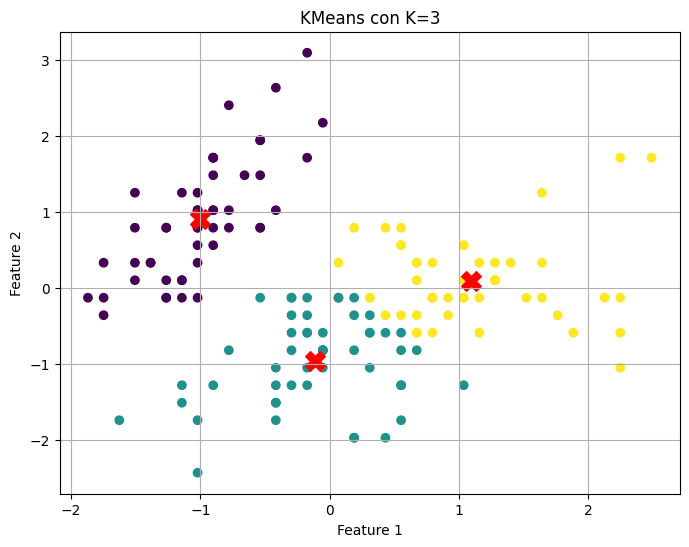

In [17]:
K = 3                                # K seleccionado

labels, centroids, inertia = kmeans(X, K)
                                       # Ejecuta KMeans

plt.figure(figsize=(8,6))             # Crear figura

plt.scatter(
    X[:,0],
    X[:,1],
    c=labels,                          # Color según cluster
    cmap='viridis'
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    color='red',
    marker='X',
    s=200
)
                                       # Dibujar centroides

plt.title(f"KMeans con K={K}")        # Título

plt.xlabel("Feature 1")               # Eje X
plt.ylabel("Feature 2")               # Eje Y

plt.grid(True)                        # Cuadrícula

plt.show()                            # Mostrar

### Conclusión
La gráfica permite visualizar cómo KMeans separó los grupos y dónde quedaron los centroides.


## CELDA 9 — Método del codo

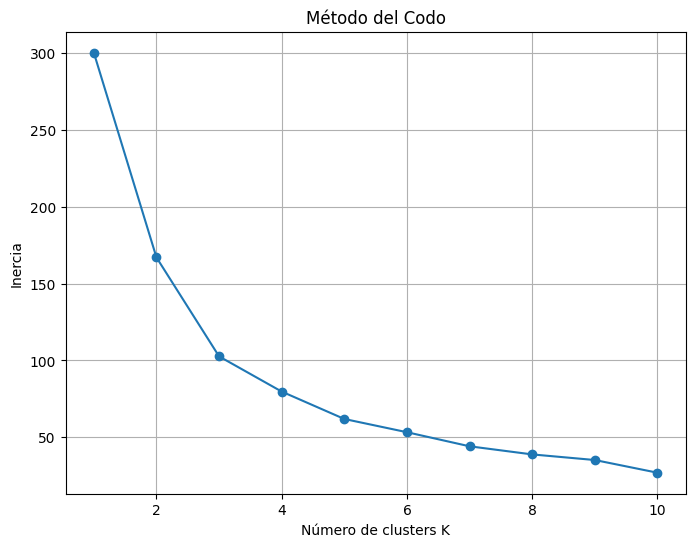

In [18]:
plt.figure(figsize=(8,6))            # Tamaño figura

plt.plot(
    list(K_values),                  # Valores K
    best_inertias,                   # Inercias
    marker='o'
)

plt.xlabel("Número de clusters K")   # Etiqueta X

plt.ylabel("Inercia")                # Etiqueta Y

plt.title("Método del Codo")         # Título

plt.grid(True)                       # Cuadrícula

plt.show()                           # Mostrar

# Conclusiones Generales

- KMeans es un algoritmo de clustering no supervisado.
- La inercia mide qué tan compactos son los clusters.
- El método del codo ayuda a elegir el mejor valor de K.
- En el dataset Iris normalmente el mejor K es cercano a 3.
